In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

In [10]:
# Prepare dataset and format timestamps
df = pd.read_csv("../data/processed_data/NYC_combined_data.csv")
df['datetimeUtc'] = pd.to_datetime(df['datetimeUtc'])

# Reshape data
df_wide = df.pivot(index='datetimeUtc', columns='parameter', values='value')
df_wide = df_wide.sort_index()

# Add time-based features
df_wide['hour'] = df_wide.index.hour
df_wide['dayofweek'] = df_wide.index.dayofweek
df_wide['month'] = df_wide.index.month
df_wide['is_weekend'] = df_wide.index.dayofweek.isin([5, 6]).astype(int)
df_wide['is_rushhour'] = df_wide.index.hour.isin([7, 8, 9, 17, 18, 19]).astype(int)

In [11]:
# Load and prepare wind/pressure data
wind = pd.read_csv("../data/processed_data/NYC_wind_pressure.csv")
wind['datetimeUtc'] = pd.to_datetime(wind['datetimeUtc'])
wind = wind.drop(columns=['station'])

# Clean numeric fields
wind['wind_speed'] = pd.to_numeric(wind['wind_speed'], errors='coerce')
wind['wind_direction'] = pd.to_numeric(wind['wind_direction'], errors='coerce')
wind['pressure'] = pd.to_numeric(wind['pressure'], errors='coerce')

# Transform wind direction for modeling
wind['wind_dir_sin'] = np.sin(np.radians(wind['wind_direction']))
wind['wind_dir_cos'] = np.cos(np.radians(wind['wind_direction']))

# Aggregate to hourly data
wind = wind.set_index('datetimeUtc')
wind = wind.resample('h').mean()

print(wind.head())
print(wind.isnull().sum())

                     wind_speed  wind_direction     pressure  wind_dir_sin  \
datetimeUtc                                                                  
2025-04-01 00:00:00    0.000000        0.000000  1001.020000      0.000000   
2025-04-01 01:00:00    3.000000      125.000000  1002.285000     -0.469846   
2025-04-01 02:00:00    2.250000       88.750000  1002.412500     -0.236254   
2025-04-01 03:00:00    2.800000      150.000000  1002.506000     -0.546410   
2025-04-01 04:00:00    2.666667      174.444444  1002.256667     -0.434368   

                     wind_dir_cos  
datetimeUtc                        
2025-04-01 00:00:00      1.000000  
2025-04-01 01:00:00      0.328990  
2025-04-01 02:00:00      0.384208  
2025-04-01 03:00:00      0.200000  
2025-04-01 04:00:00     -0.239965  
wind_speed          51
wind_direction    1611
pressure            49
wind_dir_sin      1611
wind_dir_cos      1611
dtype: int64


In [10]:
# Merge wind data into main dataset
df_wide.index = df_wide.index.tz_localize(None)
df_wide = df_wide.merge(wind[['wind_speed', 'wind_dir_sin', 'wind_dir_cos', 'pressure']],
                        left_index=True, right_index=True, how='left')

# Handle missing values after merge
df_wide[['wind_speed', 'wind_dir_sin', 'wind_dir_cos', 'pressure']] = \
    df_wide[['wind_speed', 'wind_dir_sin', 'wind_dir_cos', 'pressure']].ffill()

df_wide = df_wide.dropna()
print(df_wide.shape)
print(df_wide.isnull().sum())

(8010, 12)
pm25                0
relativehumidity    0
temperature         0
hour                0
dayofweek           0
month               0
is_weekend          0
is_rushhour         0
wind_speed          0
wind_dir_sin        0
wind_dir_cos        0
pressure            0
dtype: int64


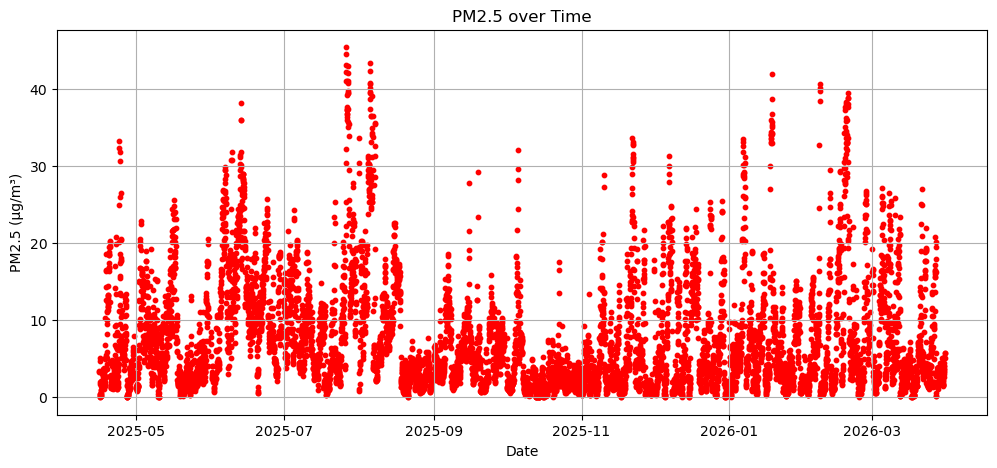

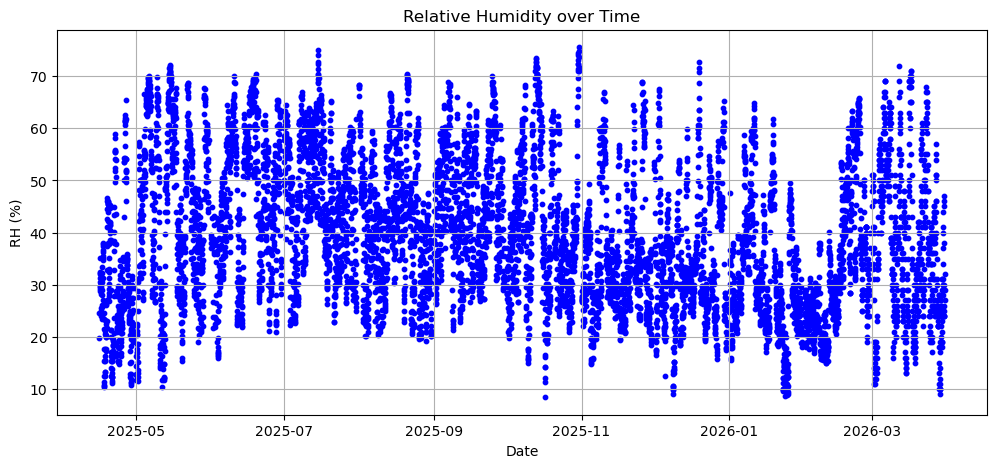

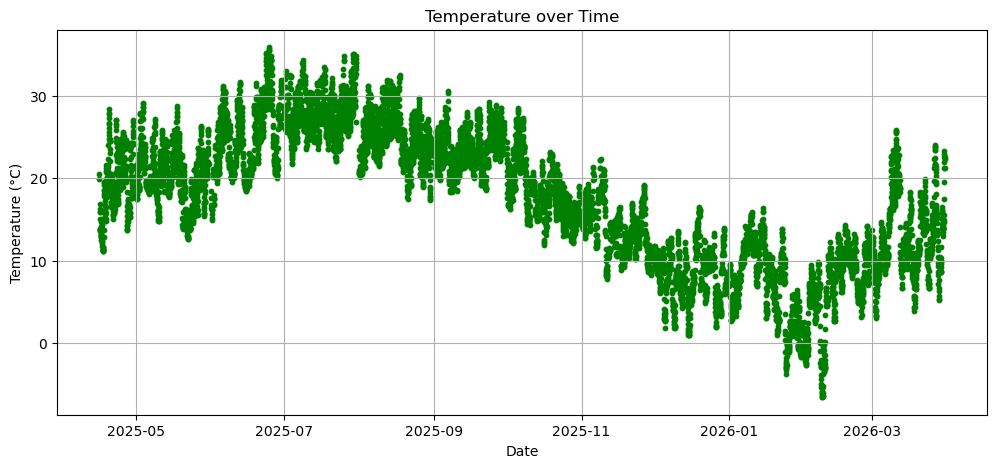

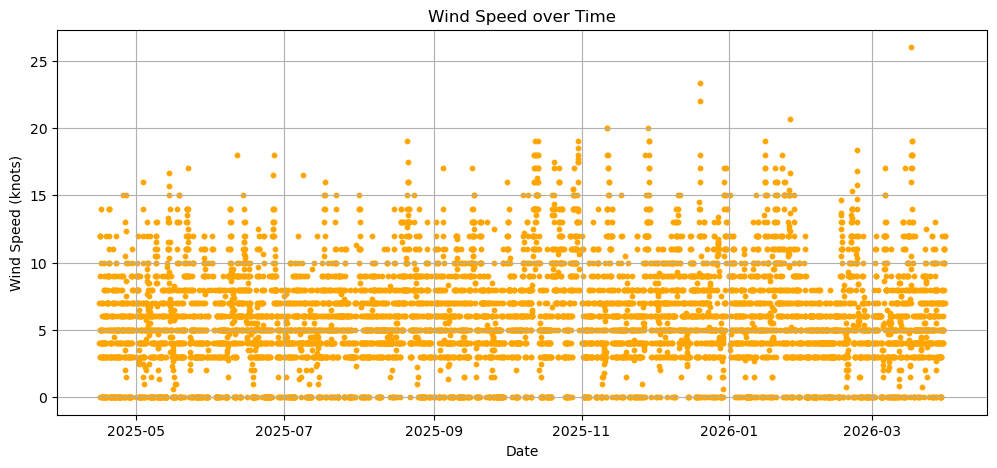

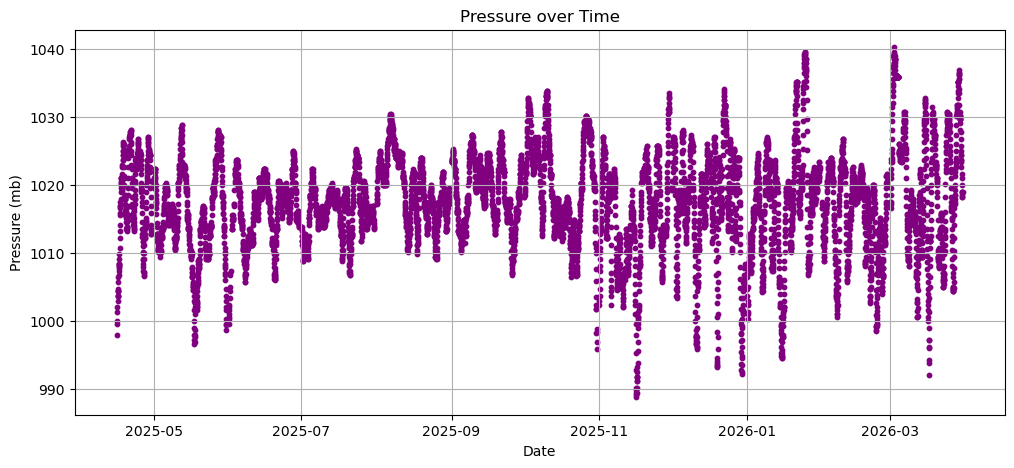

In [59]:
variables = {
    'pm25': ('PM2.5 over Time', 'PM2.5 (µg/m³)', 'red'),
    'relativehumidity': ('Relative Humidity over Time', 'RH (%)', 'blue'),
    'temperature': ('Temperature over Time', 'Temperature (°C)', 'green'),
    'wind_speed': ('Wind Speed over Time', 'Wind Speed (knots)', 'orange'),
    'pressure': ('Pressure over Time', 'Pressure (mb)', 'purple')
}

# Generate scatter plots for each variable
for col, (title, ylabel, color) in variables.items():
    plt.figure(figsize=(12, 5))
    plt.scatter(df_wide.index, df_wide[col], color=color, s=10)
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

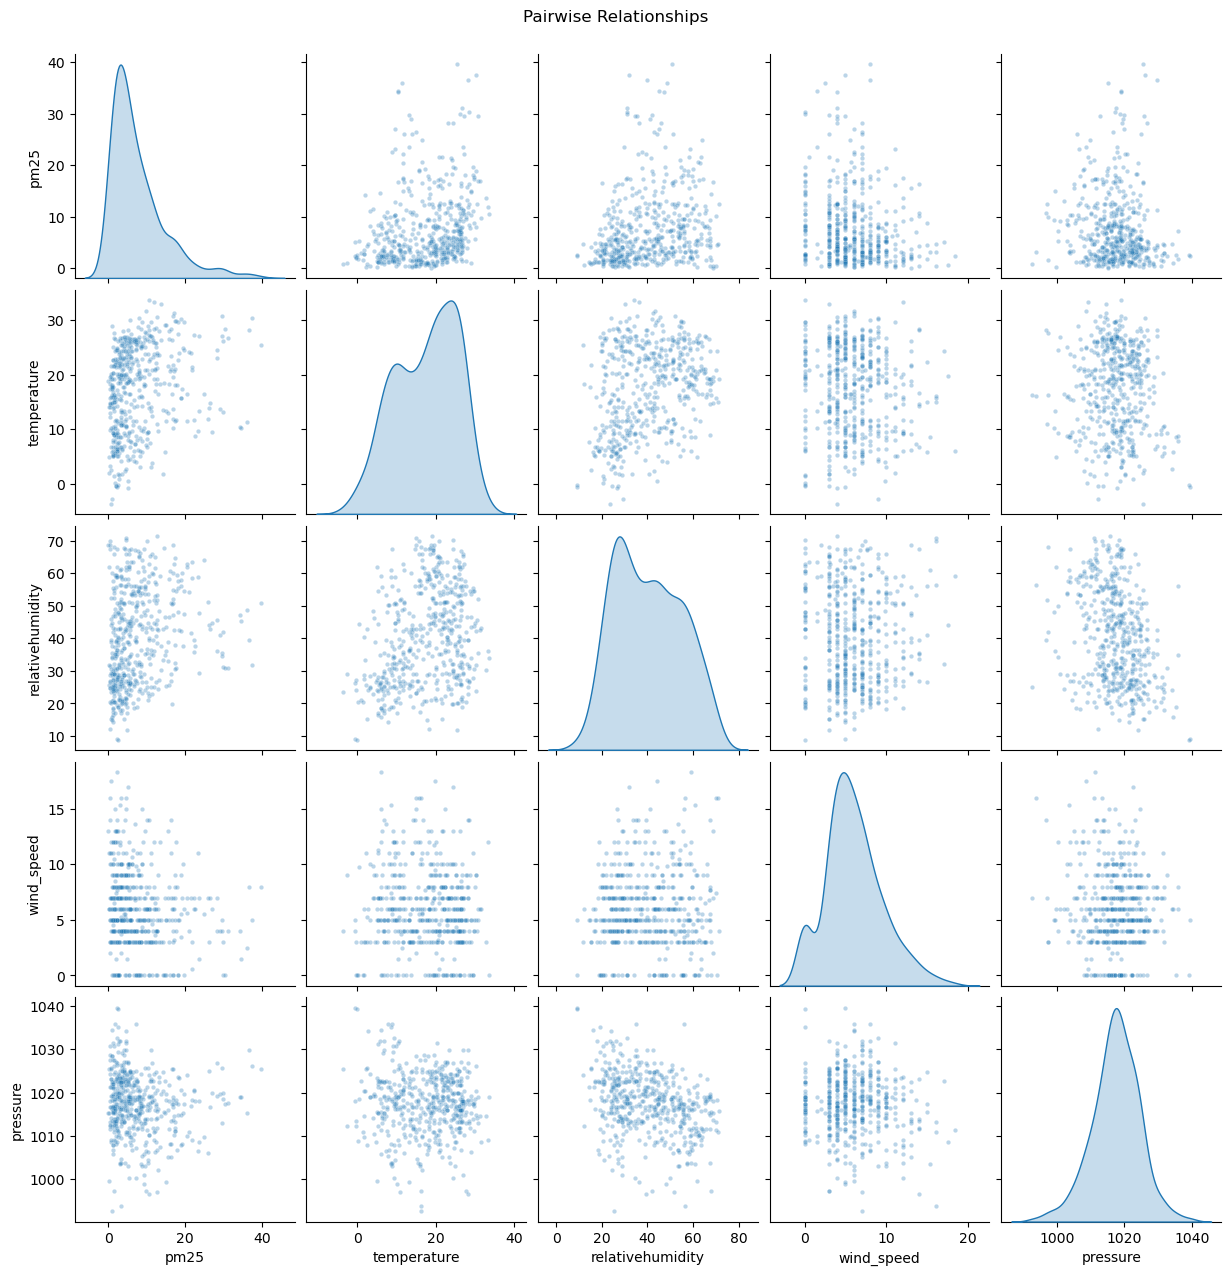

In [58]:
cols = ['pm25', 'temperature', 'relativehumidity', 'wind_speed', 'pressure']
sample = df_wide[cols].sample(500, random_state=42)

# Plot pairwise relationships between variables
sns.pairplot(sample, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()

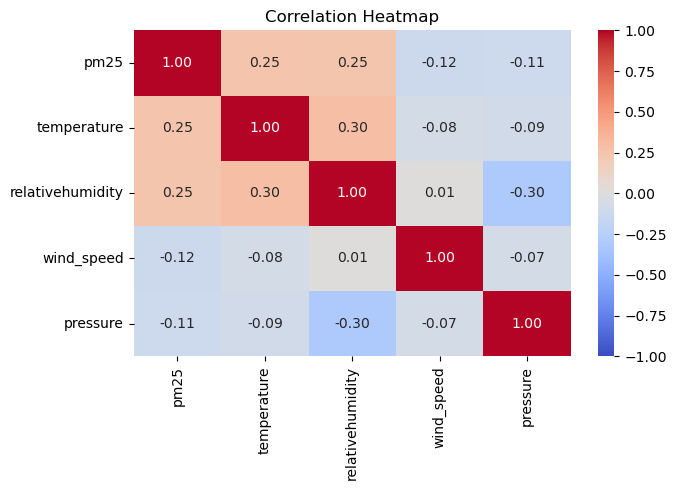

In [56]:
cols = ['pm25', 'temperature', 'relativehumidity', 'wind_speed', 'pressure']
corr = df_wide[cols].corr()

# Visualize correlations using a heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

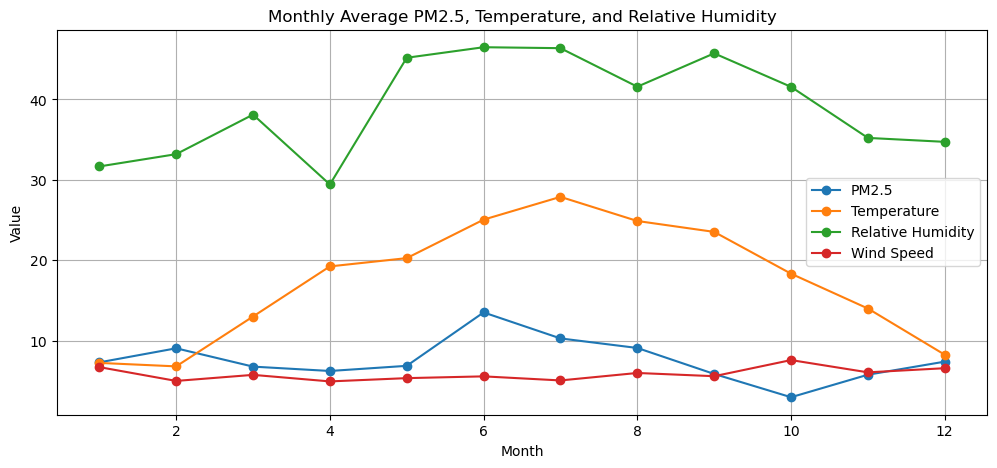

In [54]:
# Compute monthly averages
monthly_avg = df_wide.groupby('month')[['pm25', 'temperature', 'relativehumidity', "wind_speed"]].mean()

# Plot monthly trends
monthly_avg.plot(marker='o', figsize=(12, 5))
plt.title('Monthly Average PM2.5, Temperature, and Relative Humidity')
plt.xlabel('Month')
plt.ylabel('Value')
plt.legend(['PM2.5', 'Temperature', 'Relative Humidity', "Wind Speed"])
plt.grid(True)
plt.show()

In [11]:
# Define features and target variable for modeling
X = df_wide[['temperature', 'relativehumidity', 'wind_speed', 'wind_dir_sin', 'wind_dir_cos', 'pressure', 'hour', 'dayofweek', 
             'month', 'is_weekend', 'is_rushhour']]
y = df_wide['pm25']

In [18]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
# Train linear regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [26]:
# Train XGBoost regression model
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [40]:
# Train Random Forest regression model
rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestRegressor(min_samples_leaf=2, min_samples_split=5, n_estimators=300,
                      random_state=42)

In [43]:
# Define input conditions for prediction
temperature = 20
relativehumidity = 30
wind_speed = 10
wind_direction = 270   # degrees
wind_dir_sin = np.sin(np.radians(wind_direction))
wind_dir_cos = np.cos(np.radians(wind_direction))
pressure = 1013
hour = 9
dayofweek = 0
month = 4
is_weekend = 0
is_rushhour = 1

input_data = pd.DataFrame(
    [[temperature, relativehumidity, wind_speed, wind_dir_sin, wind_dir_cos,
      pressure, hour, dayofweek, month, is_weekend, is_rushhour]],
    columns=['temperature', 'relativehumidity', 'wind_speed', 'wind_dir_sin',
             'wind_dir_cos', 'pressure', 'hour', 'dayofweek', 'month', 'is_weekend', 'is_rushhour']
)

print("---- Input Variables ----")
print(f"Temperature:       {temperature}°C")
print(f"Relative Humidity: {relativehumidity}%")
print(f"Wind Speed:        {wind_speed} knots")
print(f"Wind Direction:    {wind_direction}° (sin: {wind_dir_sin:.4f}, cos: {wind_dir_cos:.4f})")
print(f"Pressure:          {pressure} mb")
print(f"Hour:              {hour}:00")
print(f"Day of Week:       {dayofweek} (0=Monday, 6=Sunday)")
print(f"Month:             {month}")
print(f"Is Weekend:        {is_weekend} (0=Weekday, 1=Weekend)")
print(f"Is Rush Hour:      {is_rushhour} (0=Not Rush Hour, 1=Rush Hour 7-9am or 5-7pm)")
print("-------------------------\n")

# Linear Regression Prediction
predicted_lr = lr.predict(input_data)
print(f"Linear Regression  → PM2.5: {predicted_lr[0]:.2f} µg/m³")

# XGBoost Prediction
predicted_xgb = xgb.predict(input_data)
print(f"XGBoost            → PM2.5: {predicted_xgb[0]:.2f} µg/m³")

# Random Forest Prediction
predicted_rf = rf.predict(input_data)
print(f"Random Forest      → PM2.5: {predicted_rf[0]:.2f} µg/m³")

---- Input Variables ----
Temperature:       20°C
Relative Humidity: 30%
Wind Speed:        10 knots
Wind Direction:    270° (sin: -1.0000, cos: -0.0000)
Pressure:          1013 mb
Hour:              9:00
Day of Week:       0 (0=Monday, 6=Sunday)
Month:             4
Is Weekend:        0 (0=Weekday, 1=Weekend)
Is Rush Hour:      1 (0=Not Rush Hour, 1=Rush Hour 7-9am or 5-7pm)
-------------------------

Linear Regression  → PM2.5: 6.47 µg/m³
XGBoost            → PM2.5: 4.84 µg/m³
Random Forest      → PM2.5: 6.95 µg/m³


In [44]:
# Evaluate model performance
results = {}

models = {
    'Linear Regression': (lr, y_pred_lr),
    'XGBoost': (xgb, y_pred_xgb),
    'Random Forest': (rf, y_pred_rf)
}

for name, (model, preds) in models.items():
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    results[name] = {'R²': r2, 'MSE': mse, 'RMSE': rmse}
    print(f"{name}:")
    print(f"  R²:   {r2:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}\n")

Linear Regression:
  R²:   0.1594
  MSE:  44.4625
  RMSE: 6.6680

XGBoost:
  R²:   0.6853
  MSE:  16.6447
  RMSE: 4.0798

Random Forest:
  R²:   0.7473
  MSE:  13.3674
  RMSE: 3.6561



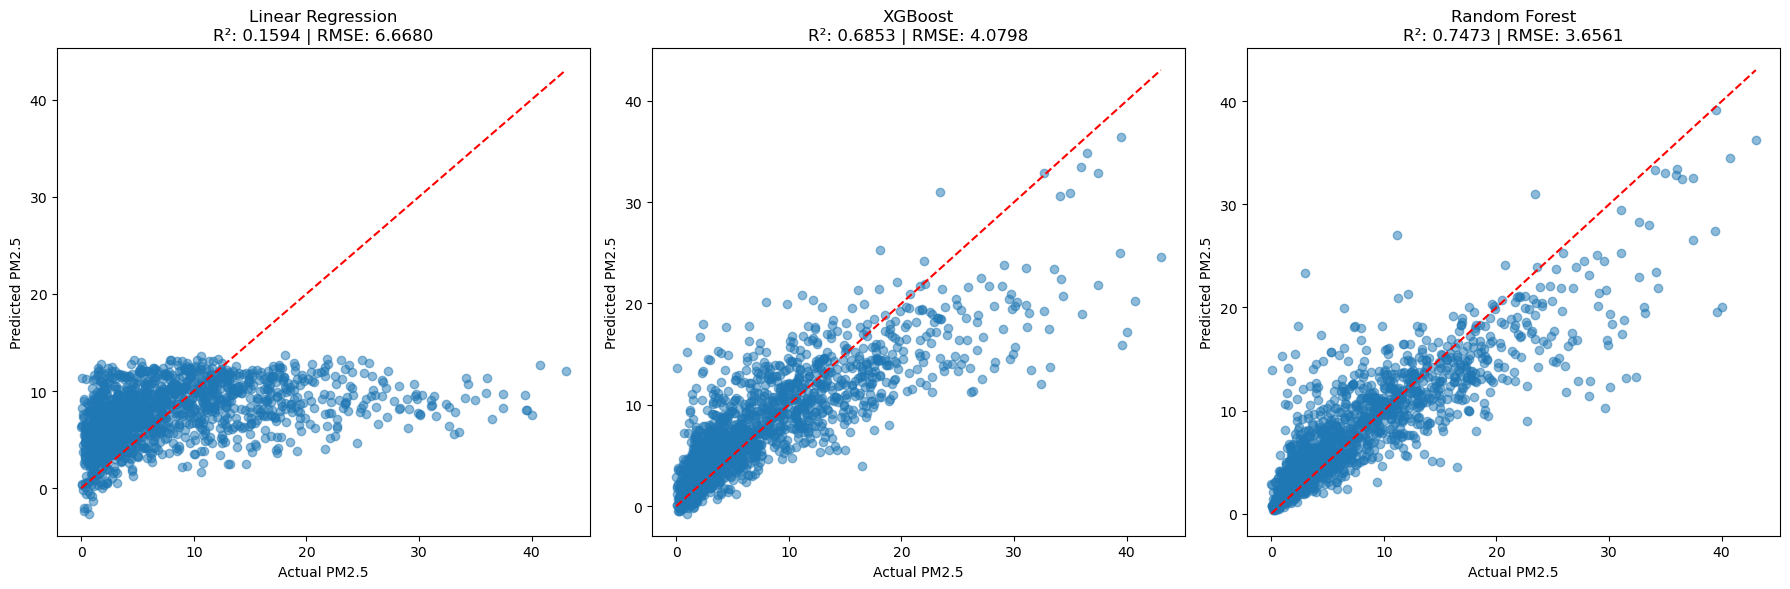

In [36]:
# Linear Regression predictions
y_pred_lr = model.predict(X_test)

# XGBoost predictions
y_pred_xgb = xgb.predict(X_test)

# Random Forest predictions
y_pred_rf = rf.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = {
    'Linear Regression': y_pred_lr,
    'XGBoost': y_pred_xgb,
    'Random Forest': y_pred_rf
}

# Plot actual vs predicted values for each model
for ax, (name, preds) in zip(axes, models.items()):
    ax.scatter(y_test, preds, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--')
    ax.set_xlabel("Actual PM2.5")
    ax.set_ylabel("Predicted PM2.5")
    ax.set_title(f"{name}\nR²: {r2_score(y_test, preds):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test, preds)):.4f}")

plt.tight_layout()
plt.show()